# Tetragram replication of `07_byte_pair_encoding_trigrams_ACE`

Replaces the BPE / trigram-pair construction with **genuine 4-grams (tetragrams)**.

Tetragram = `make_ngram(n=4)` from `generate_trigram_dataset_ace.py`:
read Roman numerals from `*_functional.lab` → drop consecutive duplicates → sliding window of 4 → keep if ≥ 3 distinct chords.

In [1]:
import os, json
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = '/workspace/dataset'
COLLECTIONS = ['lastfm', 'suno', 'udio']
OUT_DIR = '/workspace/Figures'
N = 40  # rows per panel (matches notebook num=40)

# Distinctness gate, same switch as forming_n_gram_datasets_ACE.ipynb:
#   True  = legacy: keep a window only if >=3 of 4 chords distinct (case-insensitive)
#   False = keep every window after consecutive de-duplication, except windows
#           built from a single root (i I i I, iv IV iv IV, ...). Outputs get
#           the suffix _gate_false.
APPLY_DISTINCTNESS_GATE = False
GATE_SUFFIX = '' if APPLY_DISTINCTNESS_GATE else '_gate_false'

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# FONT — Fira Code for all plots in this notebook
# ═══════════════════════════════════════════════════════════════════════════════
plt.rcParams['font.family'] = 'Fira Code'
plt.rcParams['font.monospace'] = ['Fira Code']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Fira Code'
plt.rcParams['mathtext.it'] = 'Fira Code'
plt.rcParams['mathtext.bf'] = 'Fira Code'

In [3]:
# ---- Data loading (identical to notebook cell 3) ----
def parse_functional_lab(path):
    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'N':
                labels.append(parts[2])
    return labels

def load_chord_streams(collection_name):
    seqs = []
    root = os.path.join(BASE_DIR, collection_name)
    for song_id in os.listdir(root):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue
        tokens = parse_functional_lab(fp)
        if tokens:
            seqs.append(tokens)
    return seqs

# ---- Genuine tetragrams (make_ngram n=4) ----
def tetragrams_of_song(chords):
    filtered = []
    for i, c in enumerate(chords):
        if i == 0 or c != chords[i - 1]:
            filtered.append(c)
    out = []
    for i in range(len(filtered) - 3):
        w = tuple(filtered[i:i + 4])
        unique = len(set(x.lower() for x in w))
        if APPLY_DISTINCTNESS_GATE:
            if unique < 3:
                continue
        else:
            # Single-root window: only mode/case alternation, no real motion
            if unique == 1:
                continue
        out.append(w)
    return out

def tetragram_counts(collection_name):
    cnt = Counter()
    for chords in load_chord_streams(collection_name):
        cnt.update(tetragrams_of_song(chords))
    return cnt

print('functions defined')

functions defined


In [4]:
# ---- Count tetragrams per collection ----
tetra = {}
for col in COLLECTIONS:
    tetra[col] = tetragram_counts(col)
    print(f"{col}: {sum(tetra[col].values()):,} tetragrams, {len(tetra[col]):,} unique")

lastfm: 1,399,311 tetragrams, 168,774 unique
suno: 1,373,650 tetragrams, 90,123 unique
udio: 919,083 tetragrams, 131,332 unique


In [5]:
# ---- Cross-collection matrix ranked by a reference collection ----
def build_matrix(ref):
    top = [k for k, _ in tetra[ref].most_common(N)]
    labels, mat = [], []
    for w in top:
        labels.append('·'.join(w))  # all four chords, dot-separated
        mat.append([tetra['lastfm'].get(w, 0),
                    tetra['suno'].get(w, 0),
                    tetra['udio'].get(w, 0)])
    return labels, np.array(mat), top

def plot_panel(ref, fname):
    labels, mat, top = build_matrix(ref)
    # ---- styling identical to original 07 notebook ----
    t_size = 18
    col_width_in = 2
    row_height_in = 0.25
    fig_w = col_width_in * len(COLLECTIONS) + 1.0
    fig_h = row_height_in * len(labels) + 2.0
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(mat, xticklabels=COLLECTIONS, yticklabels=labels,
                cmap='Greys', annot=True, fmt='.0f', linewidths=0.4, cbar=False)
    ax = plt.gca()
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)
    plt.ylabel('Tetragrams', fontsize=18)
    plt.tight_layout()
    os.makedirs(OUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUT_DIR, fname + '.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(OUT_DIR, fname + '.pdf'), bbox_inches='tight')
    plt.show()
    return labels, mat, top

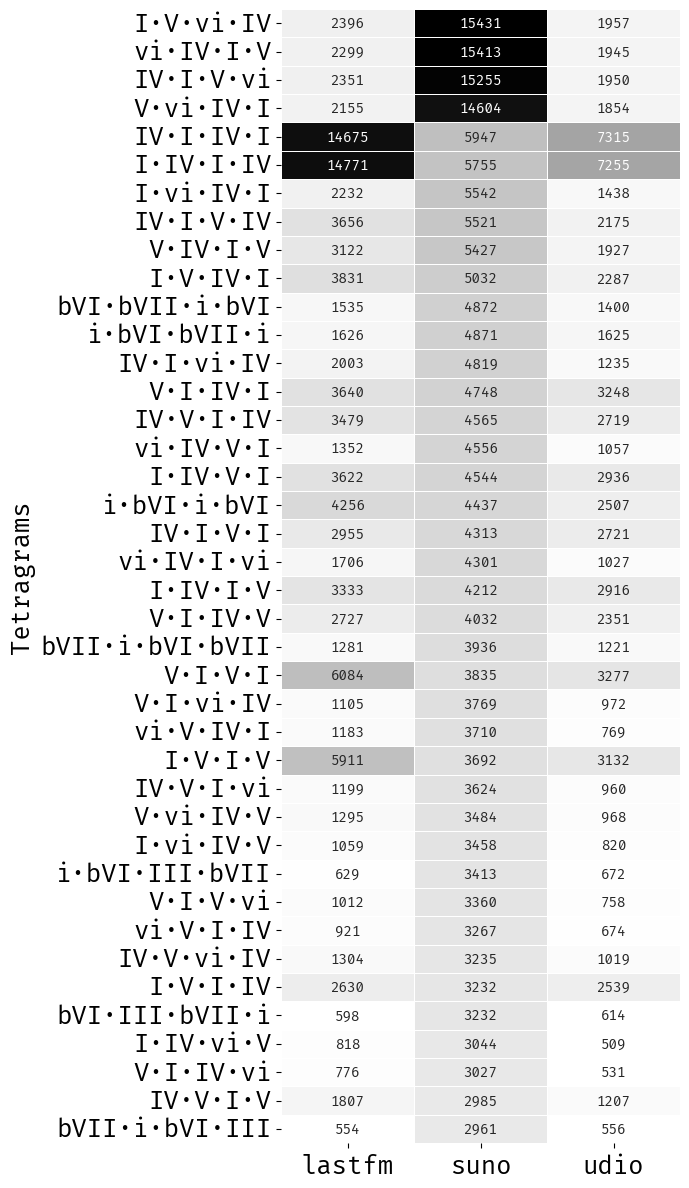

In [6]:
# ---- Suno-ranked panel (left) ----
suno_labels, suno_mat, suno_top = plot_panel('suno', f'tetragram_suno_ranked{GATE_SUFFIX}')

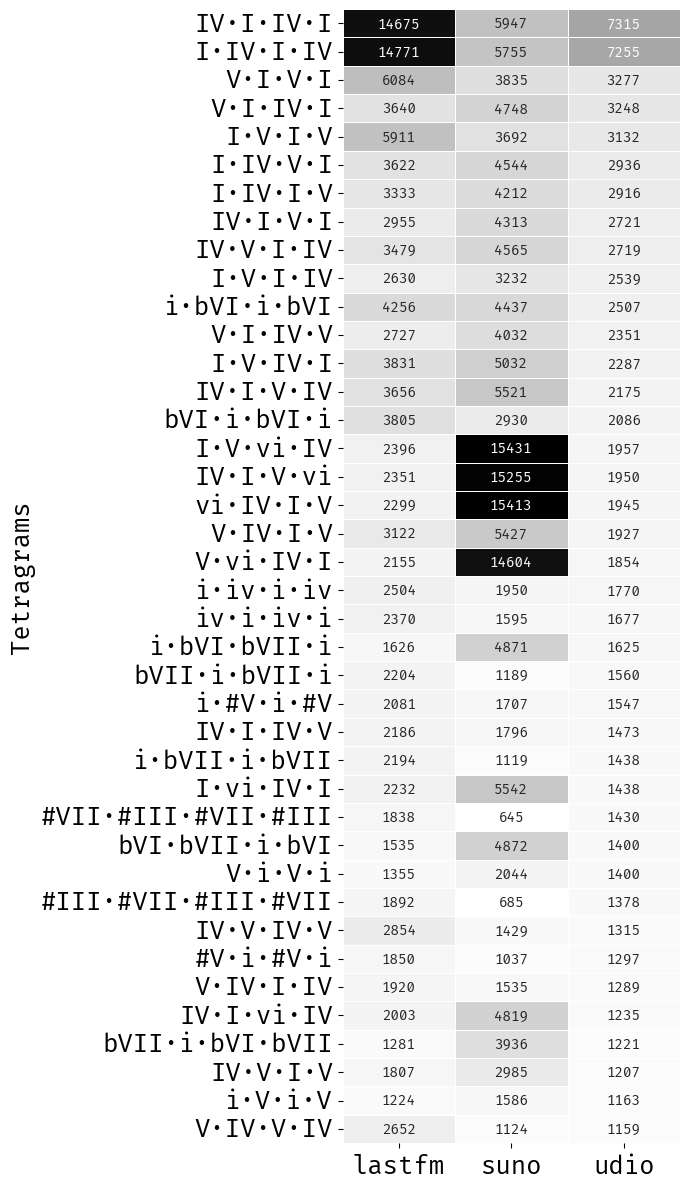

In [7]:
# ---- Udio-ranked panel (right) ----
udio_labels, udio_mat, udio_top = plot_panel('udio', f'tetragram_udio_ranked{GATE_SUFFIX}')

In [8]:
# ---- Cross-collection correlations on the full tetragram vocabulary ----
def corr(a, b):
    keys = set(tetra[a]) | set(tetra[b])
    va = np.array([tetra[a].get(k, 0) for k in keys])
    vb = np.array([tetra[b].get(k, 0) for k in keys])
    return float(np.corrcoef(va, vb)[0, 1])

corrs = {'lastfm-udio': corr('lastfm', 'udio'),
         'lastfm-suno': corr('lastfm', 'suno'),
         'suno-udio':   corr('suno', 'udio')}
for k, v in corrs.items():
    print(f"{k}: r = {v:.3f}")

lastfm-udio: r = 0.962
lastfm-suno: r = 0.638
suno-udio: r = 0.737


In [9]:
# ---- Dump numbers for the paper ----
def panel_dump(labels, mat):
    return [{"tetragram": lab, "lastfm": int(r[0]), "suno": int(r[1]), "udio": int(r[2])}
            for lab, r in zip(labels, mat)]

out = {"totals": {c: int(sum(tetra[c].values())) for c in COLLECTIONS},
       "unique": {c: int(len(tetra[c])) for c in COLLECTIONS},
       "correlations": corrs,
       "suno_ranked": panel_dump(suno_labels, suno_mat),
       "udio_ranked": panel_dump(udio_labels, udio_mat)}
with open(os.path.join(OUT_DIR, f'replication_numbers{GATE_SUFFIX}.json'), 'w') as f:
    json.dump(out, f, indent=2)

print('Suno-ranked top 15 (Lastfm / Suno / Udio):')
for row in out['suno_ranked'][:15]:
    print(f"  {row['tetragram']:<22} {row['lastfm']:>7} {row['suno']:>7} {row['udio']:>7}")

Suno-ranked top 15 (Lastfm / Suno / Udio):
  I·V·vi·IV                 2396   15431    1957
  vi·IV·I·V                 2299   15413    1945
  IV·I·V·vi                 2351   15255    1950
  V·vi·IV·I                 2155   14604    1854
  IV·I·IV·I                14675    5947    7315
  I·IV·I·IV                14771    5755    7255
  I·vi·IV·I                 2232    5542    1438
  IV·I·V·IV                 3656    5521    2175
  V·IV·I·V                  3122    5427    1927
  I·V·IV·I                  3831    5032    2287
  bVI·bVII·i·bVI            1535    4872    1400
  i·bVI·bVII·i              1626    4871    1625
  IV·I·vi·IV                2003    4819    1235
  V·I·IV·I                  3640    4748    3248
  IV·V·I·IV                 3479    4565    2719
